### 📚 Lab Task 2: Cleaning Up the Mess- TAWSHIF AL MEHRAB

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
grades = pd.read_csv("grades_crpt.csv")
grades.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


### Explanation
 imports the main libraries needed for data analysis and loads the grades dataset into a Pandas DataFrame,`head()` function shows the first five rows so we can quickly inspect the structure of the data

In [3]:
grades.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


In [4]:
grades.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


### Explanation
 `info()` function provides information about the dataset, including the number of rows, columns, data types, and missing values,also `describe()` function generates summary statistics such as the mean, standard deviation, minimum, and maximum values for each numerical column

In [5]:
corr_matrix = grades.drop(columns=["user_id"]).corr()
corr_matrix

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
A1,1.000000,-0.141322,0.363341,0.299973,0.242348,0.233172,-0.020569,0.212839
A2,-0.141322,1.000000,0.209836,-0.027420,0.011602,0.356759,0.031056,0.284525
A3,0.363341,0.209836,1.000000,0.189807,0.191534,-0.032497,0.145332,0.277859
A4,0.299973,-0.027420,0.189807,1.000000,0.039064,0.146504,0.223921,0.403466
A5,0.242348,0.011602,0.191534,0.039064,1.000000,0.241590,0.031902,0.018271
A6,0.233172,0.356759,-0.032497,0.146504,0.241590,1.000000,0.147876,0.246127
A7,-0.020569,0.031056,0.145332,0.223921,0.031902,0.147876,1.000000,0.380756
Final_Exam,0.212839,0.284525,0.277859,0.403466,0.018271,0.246127,0.380756,1.000000


### Explanation

 correlation matrix shows the relationship between assignment grades,& the final exam score, asmong all assignments, A4 (0.403) . A7 (0.381) have the strongest positive correlations with the final exam,so these two assignments would be the best candidates for predicting final exam performance because students who perform well on these assignments tend to achieve higher final exam scores

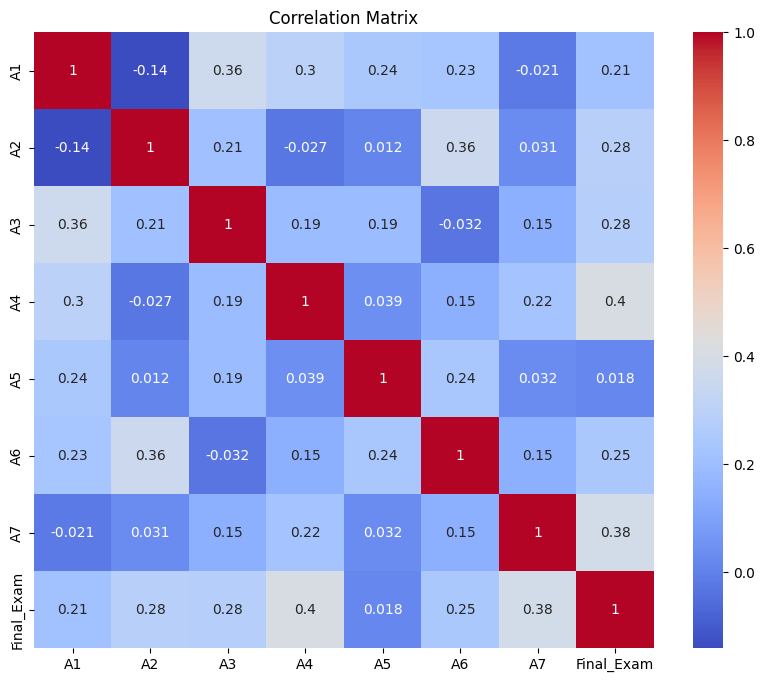

In [6]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Explanation

The heatmap provides a visual representation of the correlation matrix, darker colors indicate stronger relationships, making it easier to identify which assignments are most closely related to final exam performance.

In [7]:
grades.isnull().sum()

A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64

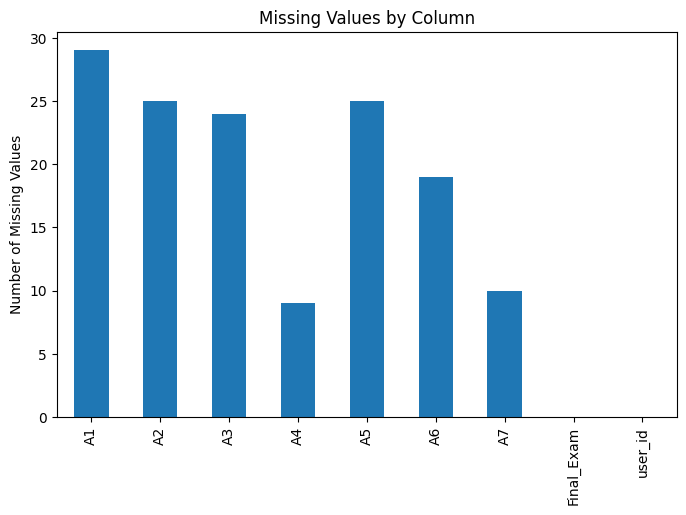

In [8]:
grades.isnull().sum().plot(kind="bar", figsize=(8,5))
plt.title("Missing Values by Column")
plt.ylabel("Number of Missing Values")
plt.show()

### Explanation

 identifies the number of missing values in each column, Visualizing missing values helps determine which assignments are most affected by incomplete data and whether imputation or other cleaning techniques may be necessary before further analysis

In [9]:
grades_drop = grades.dropna()
print("Original shape:", grades.shape)
print("After dropping missing values:", grades_drop.shape)

Original shape: (86, 9)
After dropping missing values: (13, 9)


### Explanation

 method removes all rows that contain at least one missing value, while it produces a complete dataset, it may significantly reduce the number of available records

In [10]:
grades_mean = grades.copy()
numeric_cols = grades_mean.select_dtypes(include=np.number).columns
grades_mean[numeric_cols] = grades_mean[numeric_cols].fillna(
    grades_mean[numeric_cols].mean()
)
grades_mean.isnull().sum()

A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
Final_Exam    0
user_id       0
dtype: int64

### Explanation

This replaces missing values with the mean of each column. Mean imputation preserves the size of the dataset but may be affected by extreme values and outliers

In [11]:
grades_median = grades.copy()
numeric_cols = grades_median.select_dtypes(include=np.number).columns

grades_median[numeric_cols] = grades_median[numeric_cols].fillna(
    grades_median[numeric_cols].median()
)
grades_median.isnull().sum()

A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
Final_Exam    0
user_id       0
dtype: int64

### Explanation

replaces missing values with the median of each column. median imputation is generally more robust than mean imputation because it is less sensitive to extreme values and outliers

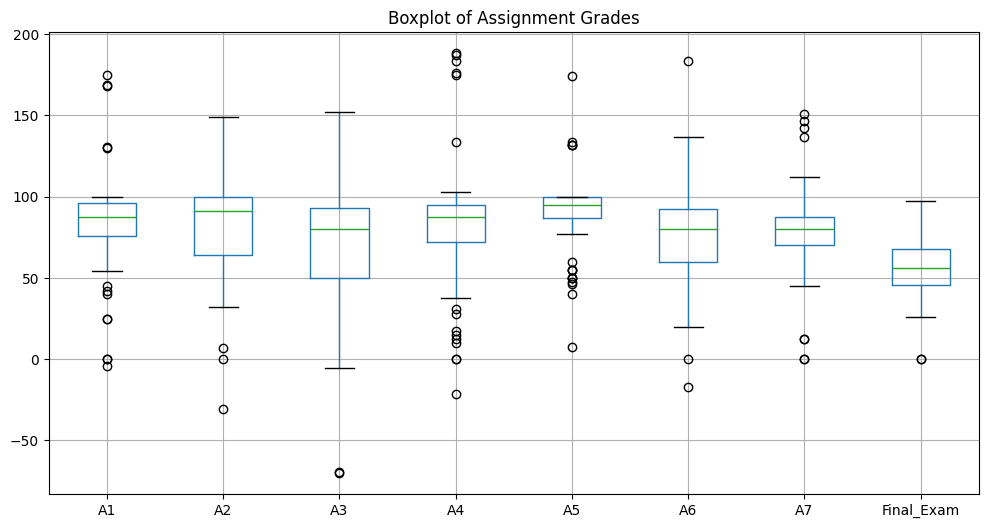

In [12]:
grades.boxplot(figsize=(12,6))
plt.title("Boxplot of Assignment Grades")
plt.show()

### Explanation
boxplot helps identify outliers by showing the distribution of values in each column, Values that fall far outside the typical range appear as individual points and may represent data entry errors or corrupted records.

In [13]:
limits = {
    "A1":100,
    "A2":115,
    "A3":100,
    "A4":105,
    "A5":100,
    "A6":110,
    "A7":100
}
for col, max_score in limits.items():
    invalid = grades[(grades[col] < 0) | (grades[col] > max_score)]
    print(f"{col}: {len(invalid)} invalid values")

A1: 6 invalid values
A2: 2 invalid values
A3: 7 invalid values
A4: 7 invalid values
A5: 5 invalid values
A6: 3 invalid values
A7: 7 invalid values


### Explanation

checks each assignment column for impossible grades- below zero or above the maximum allowed score are considered invalid and are treated as outliers that may require correction

In [15]:
grades_clean = grades.copy()
limits = {
    "A1":100,
    "A2":115,
    "A3":100,
    "A4":105,
    "A5":100,
    "A6":110,
    "A7":100
}
for col, max_score in limits.items():
    grades_clean.loc[(grades_clean[col] < 0) | (grades_clean[col] > max_score), col] = np.nan

In [16]:
numeric_cols = grades_clean.select_dtypes(include=np.number).columns
grades_clean[numeric_cols] = grades_clean[numeric_cols].fillna(
    grades_clean[numeric_cols].median()
)
grades_clean.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,80.431395,84.747674,74.430233,78.000000,87.161628,74.933721,74.051163,55.509302
std,18.833782,19.826060,22.119749,24.695339,16.888556,21.880250,18.845357,18.176777
min,0.000000,0.000000,0.000000,0.000000,7.700000,0.000000,0.000000,0.000000
25%,83.300000,79.475000,71.500000,76.850000,90.000000,70.000000,72.500000,45.850000
50%,83.300000,91.100000,80.000000,86.850000,91.000000,80.000000,78.800000,56.050000
75%,87.500000,92.900000,82.750000,92.175000,96.750000,87.000000,83.800000,67.725000
max,100.000000,114.300000,100.000000,102.500000,100.000000,110.000000,98.800000,97.500000


### Explanation

invalid grades were first identified and replaced with missing values because scores below zero or above the maximum allowed grade are not realistic, The resulting missing values were then replaced using median imputation, this preserves the dataset size while reducing the influence of extreme values on the analysis

### Conclusion

 dataset contained both missing values and invalid grade records, Missing values were addressed using mean and median imputation methods, while outliers were detected through summary statistics and boxplots. Because the dataset contained extreme values, median imputation was selected as the preferred strategy since it is less sensitive to outliers. Correlation analysis showed that A4 and A7 had the strongest relationships with final exam performance, making them the most useful assignments for predicting final exam outcomes.

In [17]:
grades_clean.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,80.431395,84.747674,74.430233,78.000000,87.161628,74.933721,74.051163,55.509302
std,18.833782,19.826060,22.119749,24.695339,16.888556,21.880250,18.845357,18.176777
min,0.000000,0.000000,0.000000,0.000000,7.700000,0.000000,0.000000,0.000000
25%,83.300000,79.475000,71.500000,76.850000,90.000000,70.000000,72.500000,45.850000
50%,83.300000,91.100000,80.000000,86.850000,91.000000,80.000000,78.800000,56.050000
75%,87.500000,92.900000,82.750000,92.175000,96.750000,87.000000,83.800000,67.725000
max,100.000000,114.300000,100.000000,102.500000,100.000000,110.000000,98.800000,97.500000


In [18]:
grades_clean.isnull().sum()

A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
Final_Exam    0
user_id       0
dtype: int64

In [19]:
grades_clean.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,80.431395,84.747674,74.430233,78.000000,87.161628,74.933721,74.051163,55.509302
std,18.833782,19.826060,22.119749,24.695339,16.888556,21.880250,18.845357,18.176777
min,0.000000,0.000000,0.000000,0.000000,7.700000,0.000000,0.000000,0.000000
25%,83.300000,79.475000,71.500000,76.850000,90.000000,70.000000,72.500000,45.850000
50%,83.300000,91.100000,80.000000,86.850000,91.000000,80.000000,78.800000,56.050000
75%,87.500000,92.900000,82.750000,92.175000,96.750000,87.000000,83.800000,67.725000
max,100.000000,114.300000,100.000000,102.500000,100.000000,110.000000,98.800000,97.500000
